In [1]:
import scanpy as sc
import pandas as pd

adata1 = sc.read_h5ad("GSE114725_clustered.h5ad")
adata2 = sc.read_h5ad("GSE176078_clustered.h5ad")

In [2]:
sc.tl.rank_genes_groups(
    adata1,
    groupby="leiden",
    method="wilcoxon"
)

sc.tl.rank_genes_groups(
    adata2,
    groupby="leiden",
    method="wilcoxon"
)

C:\Users\annam\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\annam\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\annam\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\annam\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\annam\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
C:\Users\annam\anaconda3\Lib\site-packages\scanpy\tools\_rank_gen

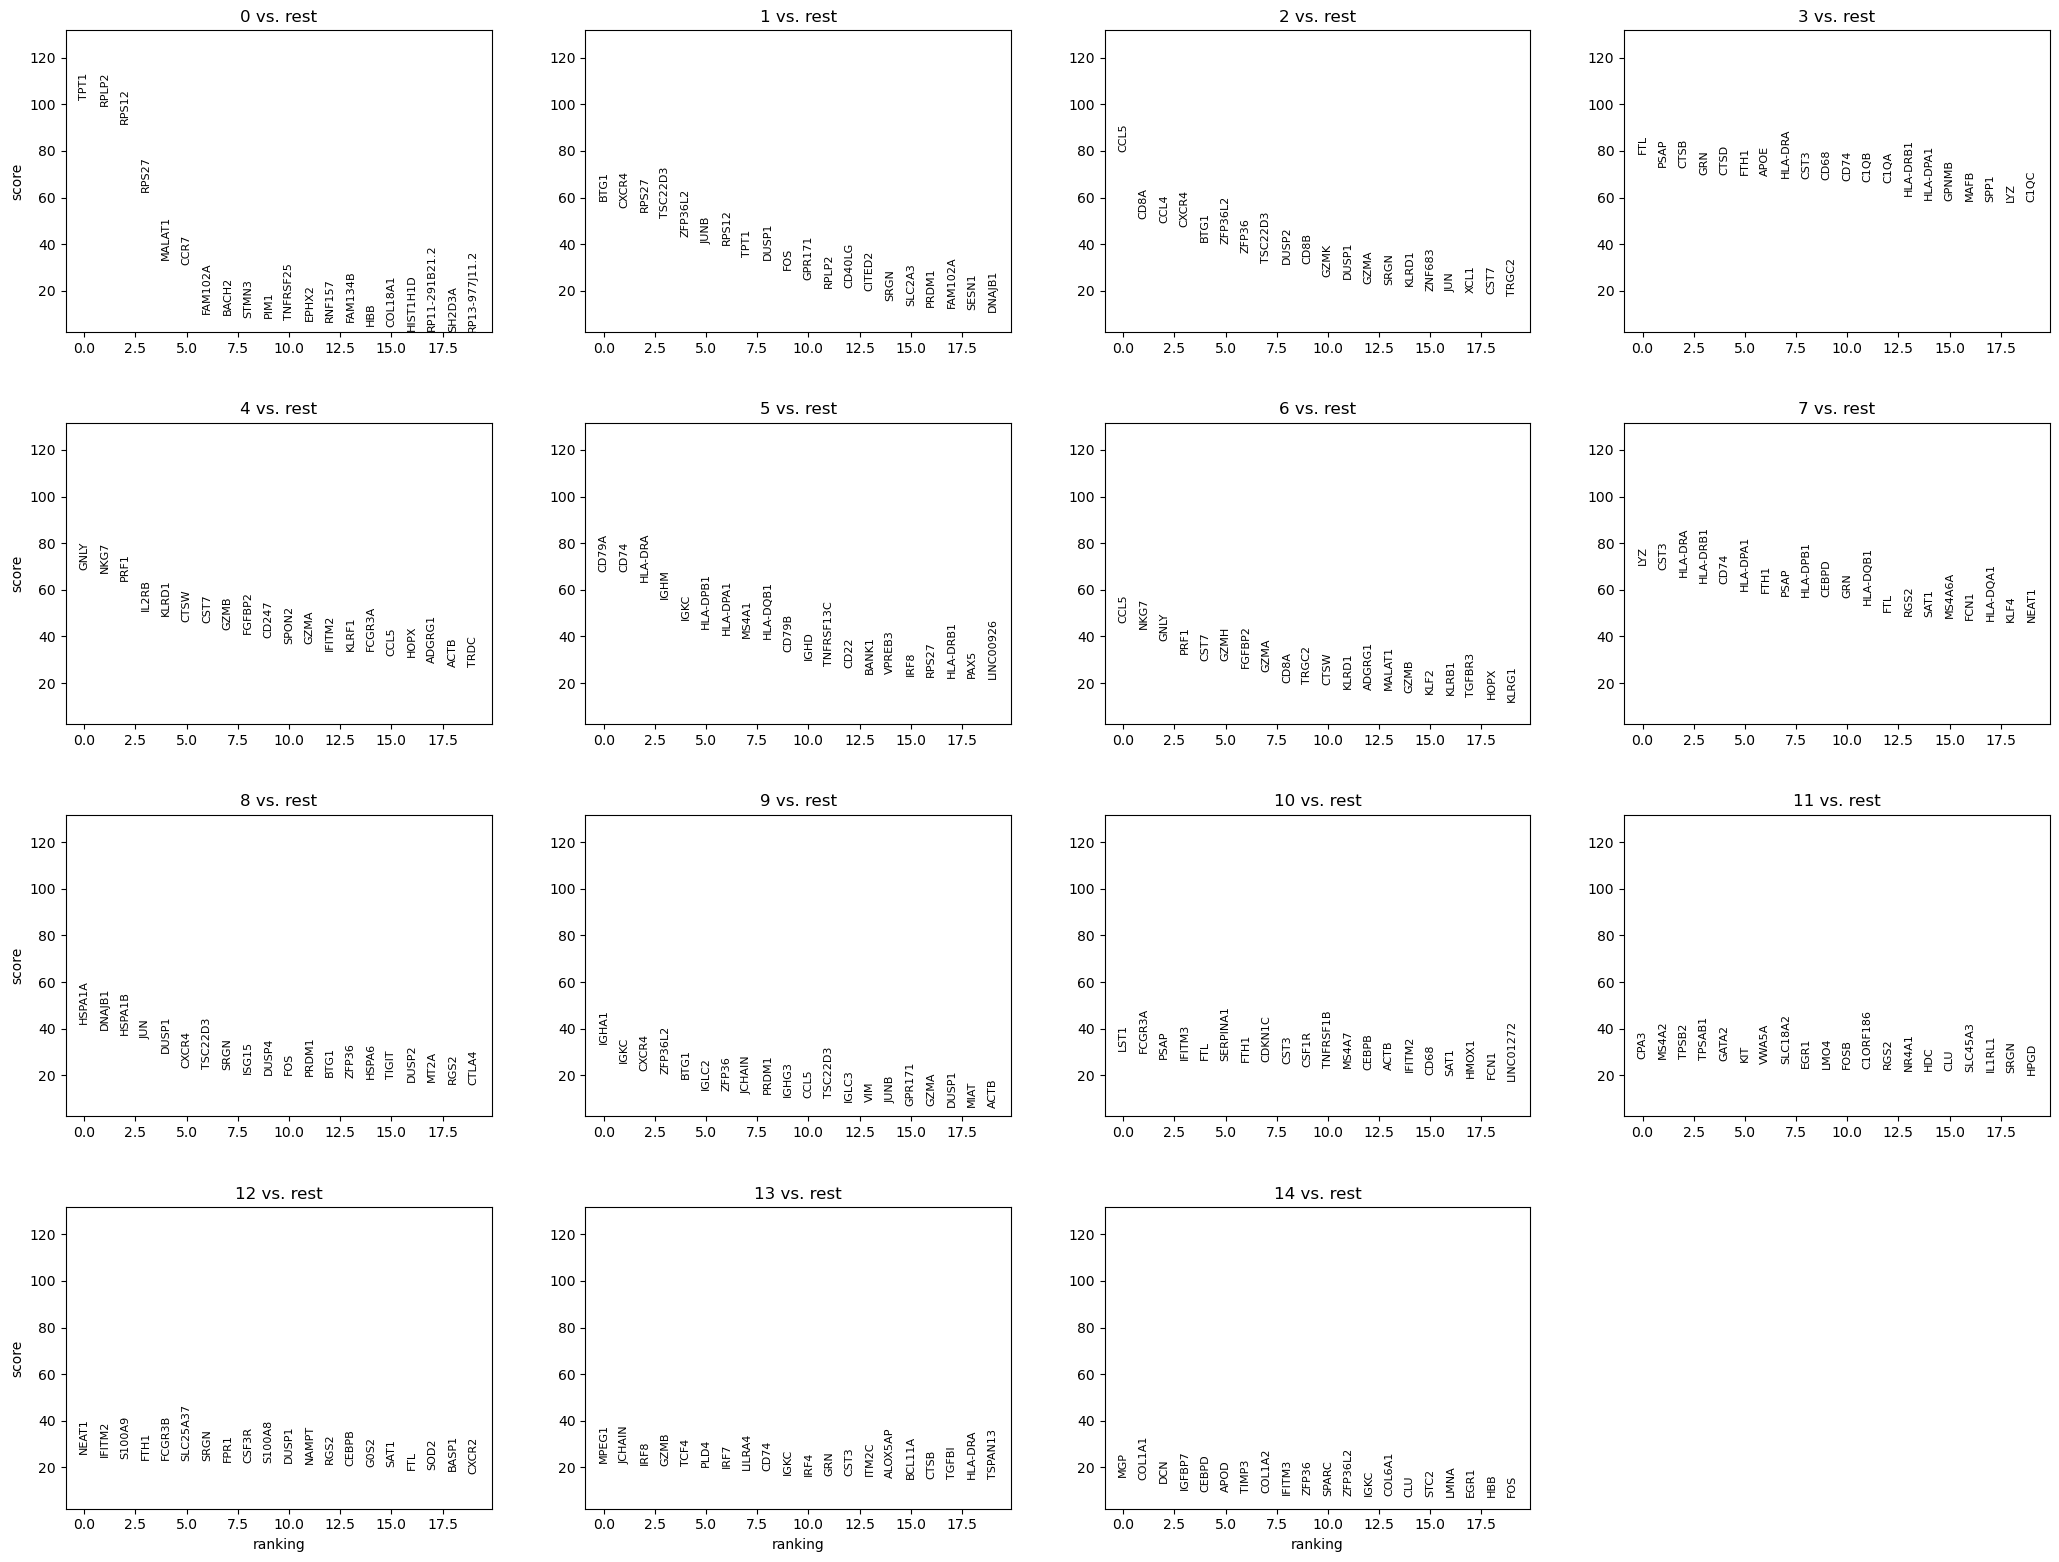

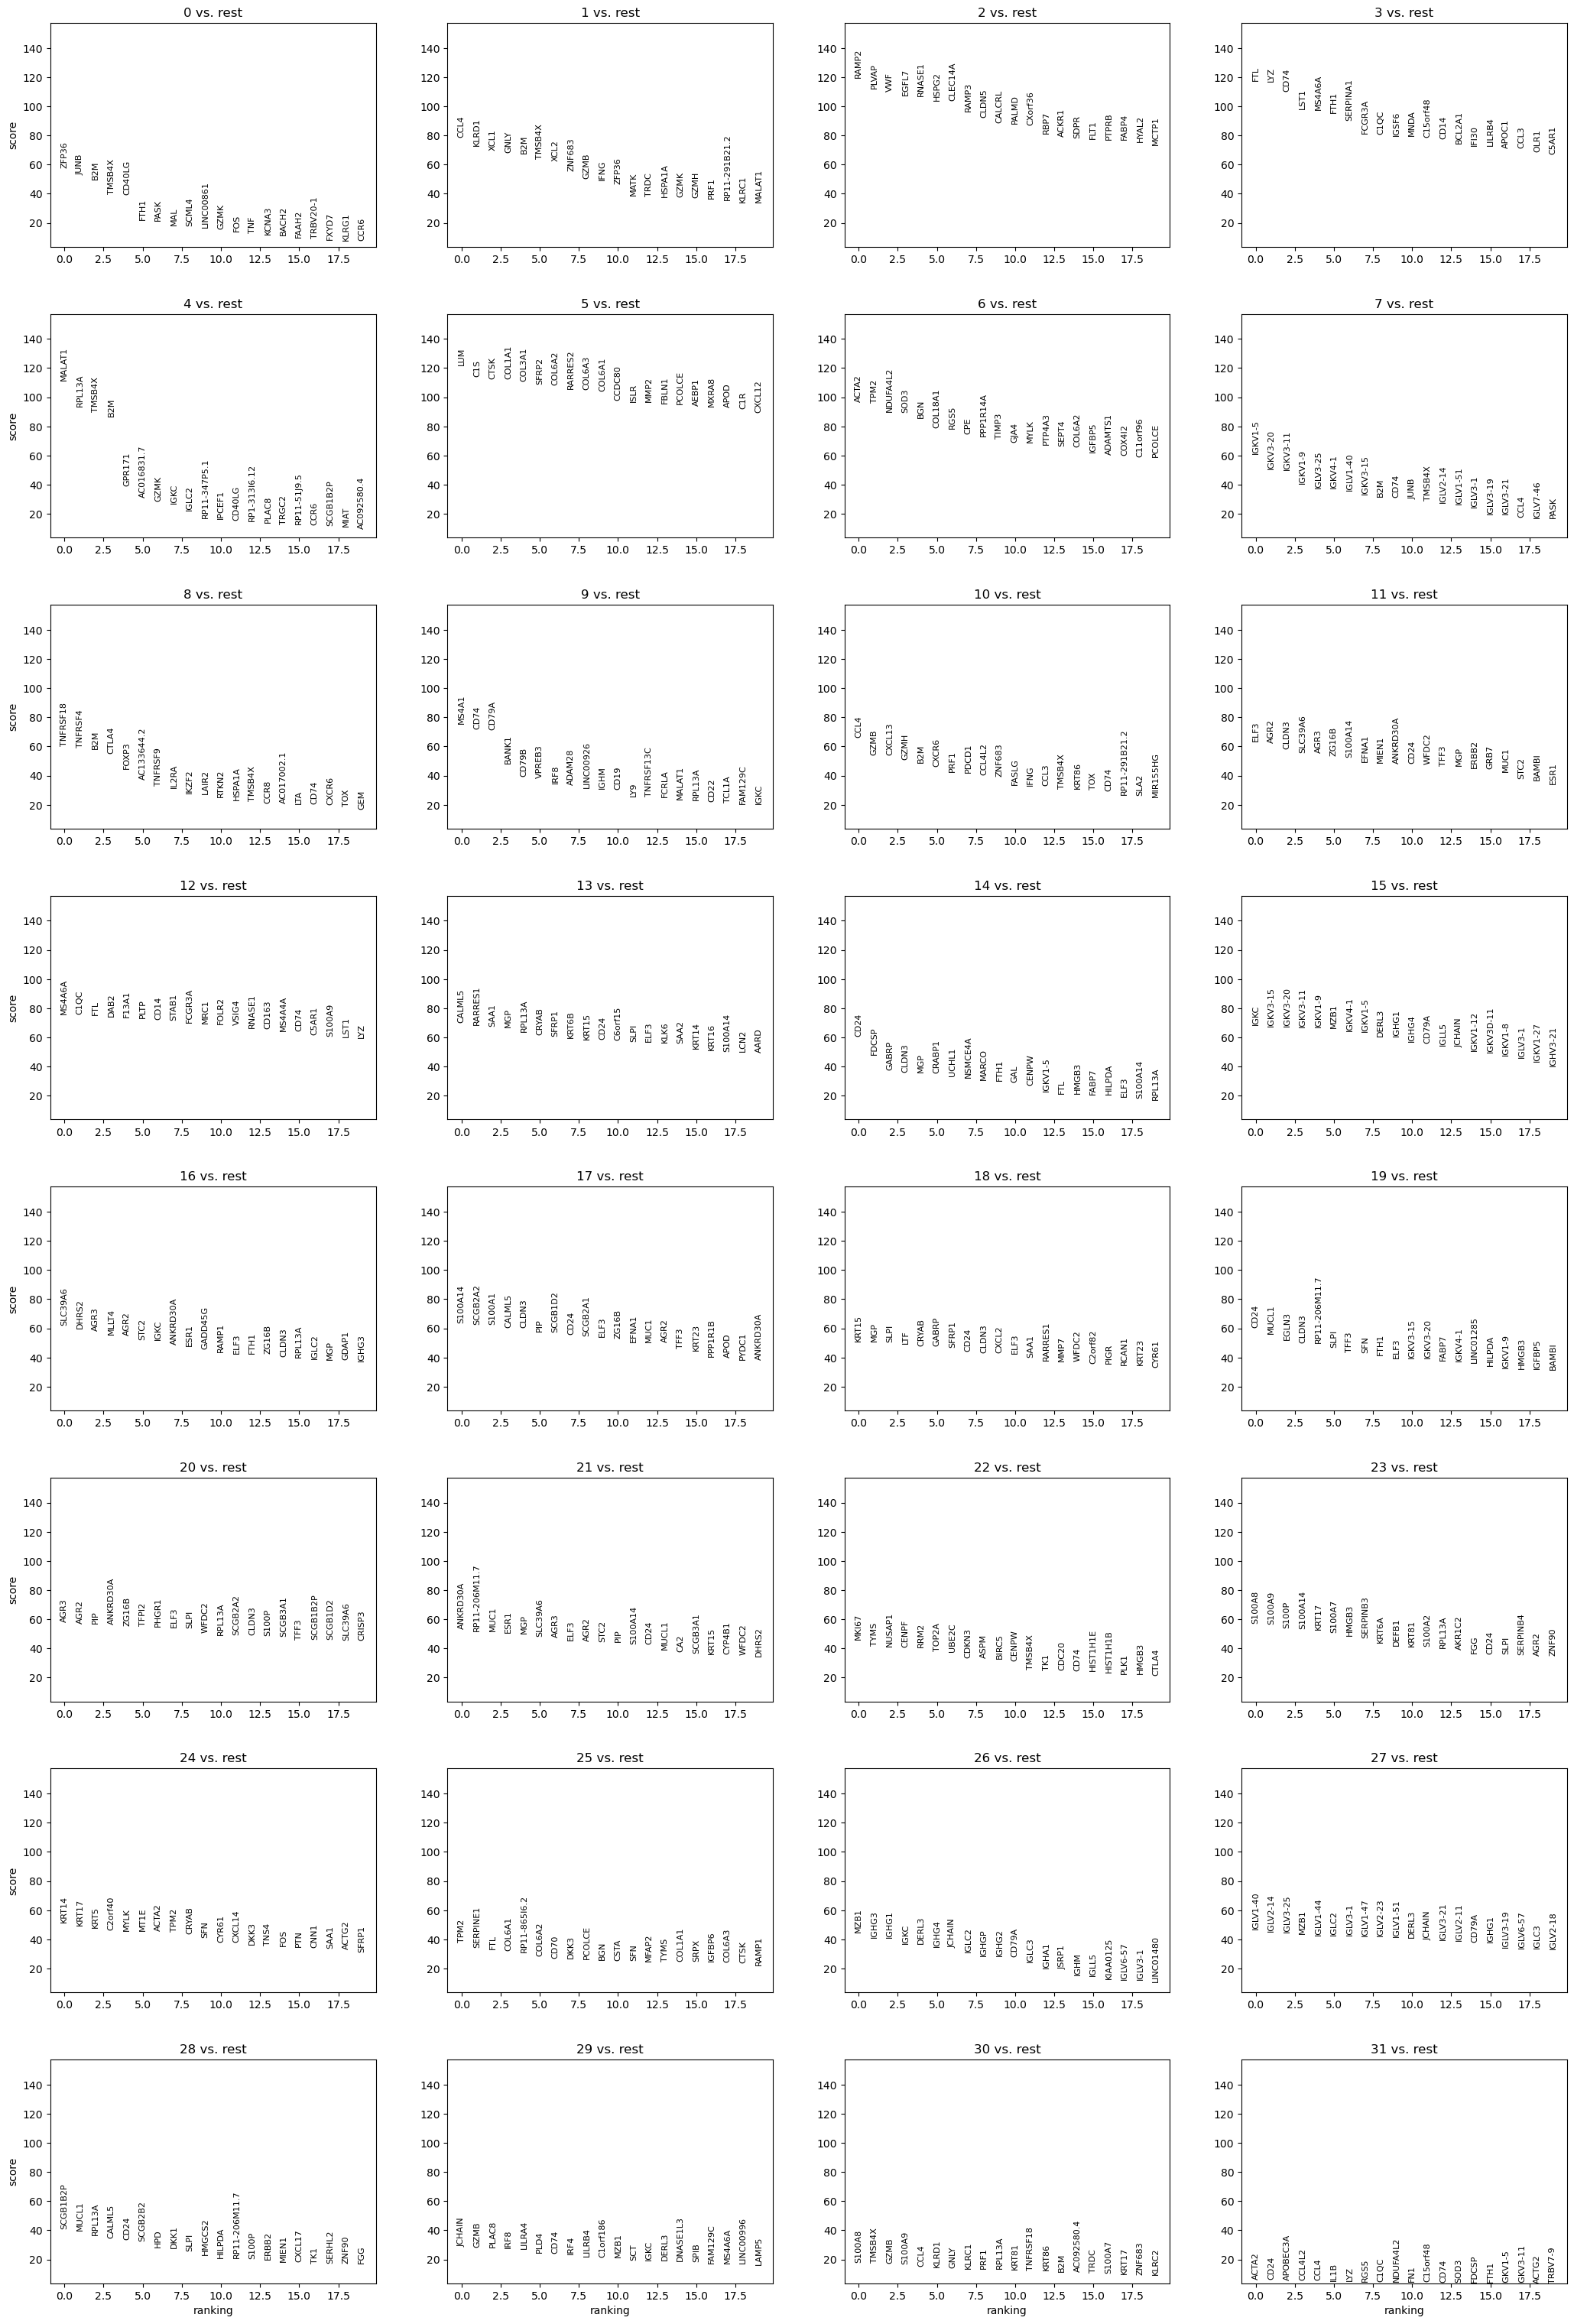

In [3]:
sc.pl.rank_genes_groups(adata1, n_genes=20)
sc.pl.rank_genes_groups(adata2, n_genes=20)

In [5]:

# Load full QC object with all genes
adata2_full = sc.read_h5ad("GSE176078_qc.h5ad")

# Load clustered HVG object with UMAP + Leiden
adata2_clustered = sc.read_h5ad("GSE176078_clustered.h5ad")

# Copy UMAP + Leiden from clustered object into full object
adata2_full.obsm["X_umap"] = adata2_clustered.obsm["X_umap"]
adata2_full.obs["leiden"] = adata2_clustered.obs["leiden"].copy()

In [15]:
broad_markers = [
    # T / NK
    "CD3D", "CD3E", "CD4", "CD8A", "NKG7", "GNLY",

    # B / plasma
    "MS4A1", "CD79A", "CD79B", "MZB1", "JCHAIN",

    # Myeloid
    "LST1", "C1QA", "C1QB", "LYZ", "FCER1G",

    # Dendritic cells
    "FCER1A", "CLEC10A", "ITGAX",

    # Epithelial / tumour
    "EPCAM", "KRT8", "KRT18", "KRT19",

    # Fibroblast / stromal
    "COL1A1", "COL1A2", "DCN", "LUM",

    # Endothelial
    "PECAM1", "VWF", "KDR"
]

# Keep only genes present in dataset
broad_markers_present = [g for g in broad_markers if g in adata2_full.var_names]

print("Markers found:", broad_markers_present)
print("Markers missing:", [g for g in broad_markers if g not in adata2_full.var_names])

Markers found: ['CD3D', 'CD3E', 'CD4', 'CD8A', 'NKG7', 'GNLY', 'MS4A1', 'CD79A', 'CD79B', 'MZB1', 'JCHAIN', 'LST1', 'C1QA', 'C1QB', 'LYZ', 'FCER1G', 'FCER1A', 'CLEC10A', 'ITGAX', 'EPCAM', 'KRT8', 'KRT18', 'KRT19', 'COL1A1', 'COL1A2', 'DCN', 'LUM', 'PECAM1', 'VWF', 'KDR']
Markers missing: []


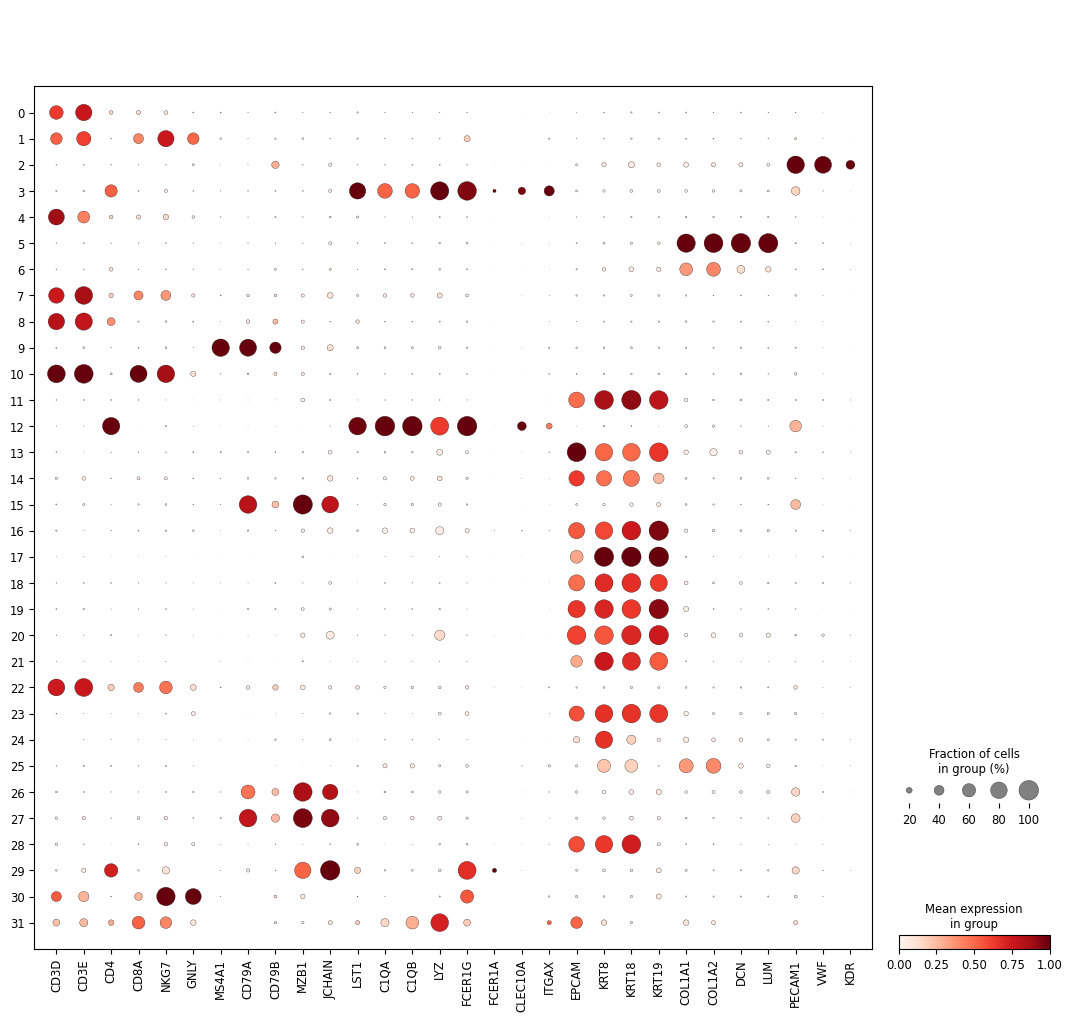

In [17]:
sc.pl.dotplot(
    adata2_full,
    var_names=broad_markers_present,
    groupby="leiden",
    standard_scale="var",
    dendrogram=False
)

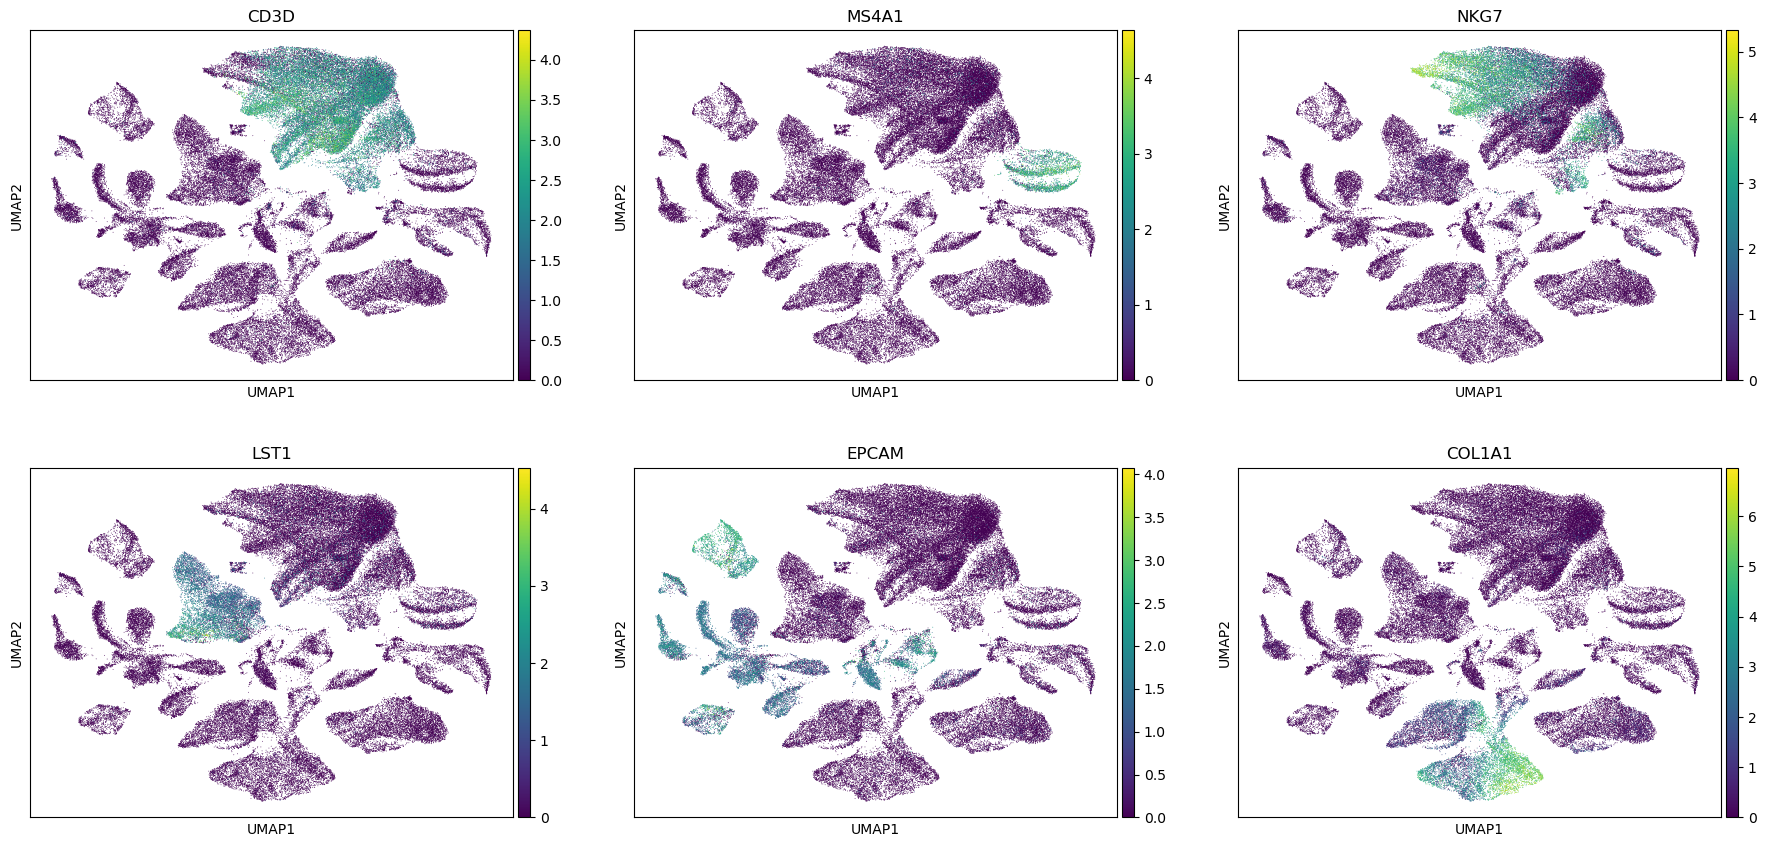

In [7]:
sc.pl.umap(
    adata2_full,
    color=[g for g in markers if g in adata2_full.var_names],
    ncols=3
)

In [5]:
adata2_full = sc.read_h5ad("GSE176078_qc.h5ad")
adata1_full = sc.read_h5ad("GSE114725_qc.h5ad")

In [8]:
# Load full QC object with all genes
adata1_full = sc.read_h5ad("GSE114725_qc.h5ad")

# Load clustered HVG object with UMAP + Leiden
adata1_clustered = sc.read_h5ad("GSE114725_clustered.h5ad")

# Copy UMAP + Leiden into full object
adata1_full.obsm["X_umap"] = adata1_clustered.obsm["X_umap"]
adata1_full.obs["leiden"] = adata1_clustered.obs["leiden"].copy()

CD3D True
MS4A1 True
NKG7 True
LST1 True
EPCAM True
COL1A1 True


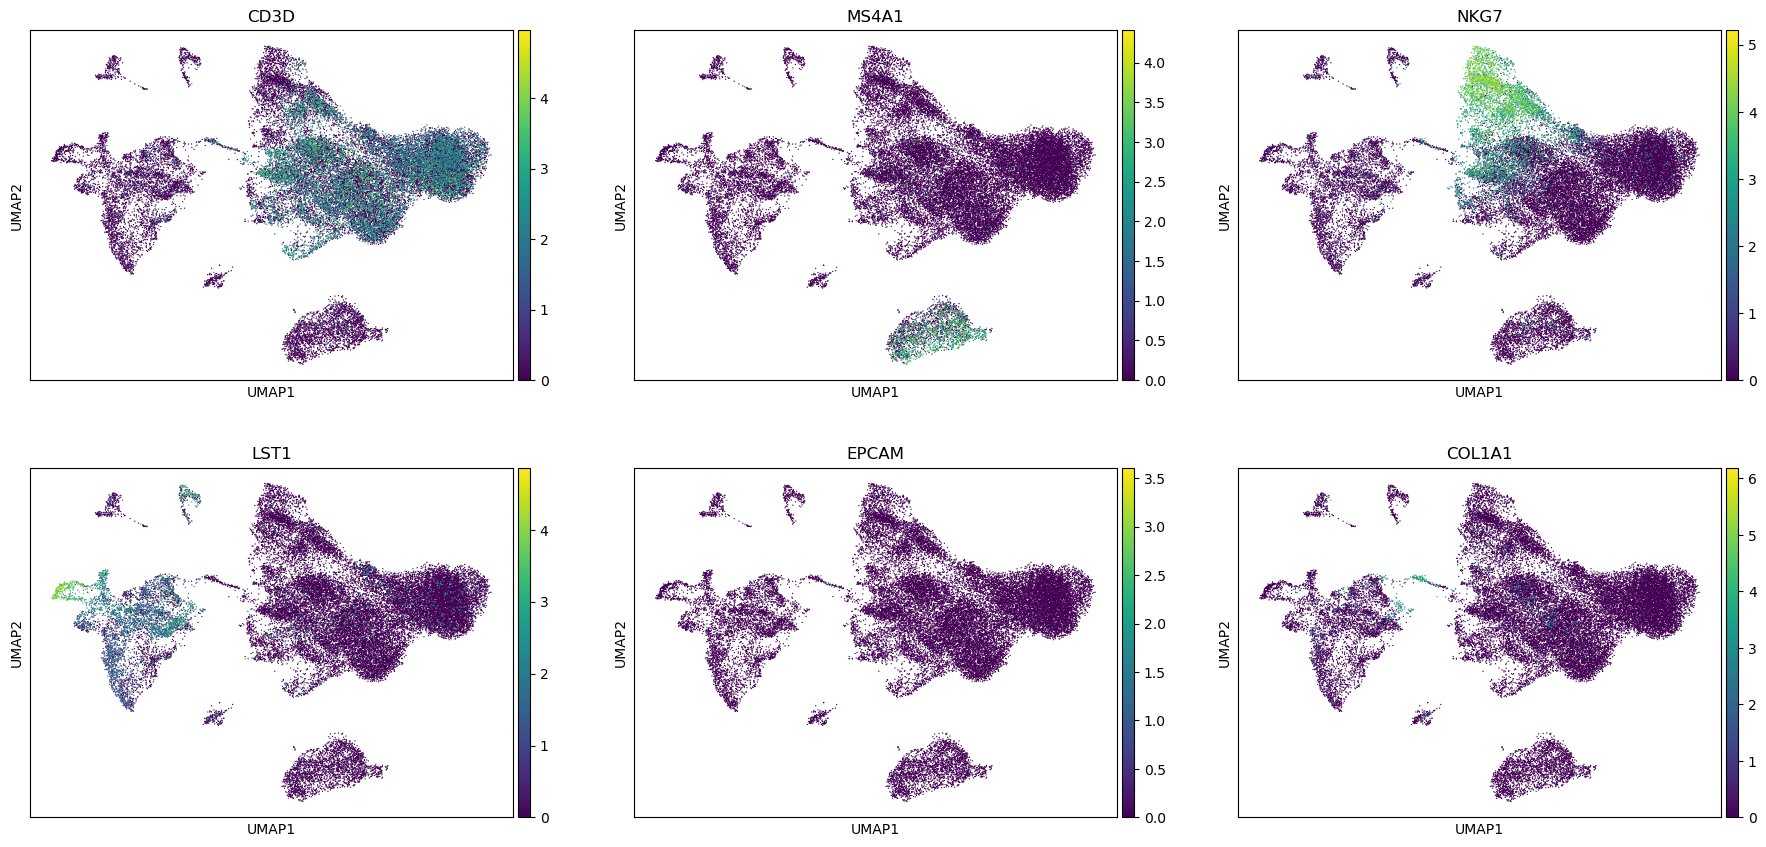

In [9]:
markers = ["CD3D", "MS4A1", "NKG7", "LST1", "EPCAM", "COL1A1"]

for gene in markers:
    print(gene, gene in adata1_full.var_names)

sc.pl.umap(
    adata1_full,
    color=[g for g in markers if g in adata1_full.var_names],
    ncols=3
)

In [10]:
adata1_full.obs["leiden"].value_counts()

leiden
0     8467
1     6117
2     3725
3     2597
4     2545
5     2462
6     2277
7     2026
8     1399
9      526
10     349
11     263
12     257
13     178
14     154
Name: count, dtype: int64

In [11]:
adata2_full.obs["leiden"].value_counts()

leiden
0     8817
1     7710
2     6503
3     6373
4     5889
5     5715
6     4745
7     3458
8     3454
9     2722
10    2718
11    2601
12    2098
13    1985
14    1668
15    1654
16    1576
17    1478
18    1348
19    1295
20    1215
21    1140
22    1131
23    1119
24    1002
25     886
26     873
27     768
28     560
29     310
30     127
31      16
Name: count, dtype: int64

In [12]:
cluster_map = {
    "0": "T cells",
    "1": "NK cells",
    "2": "Macrophages",
    "3": "B cells"
} #example oonly not final plot

In [13]:
adata1_full.obs["celltype"] = (
    adata1_full.obs["leiden"]
    .map(cluster_map)
)

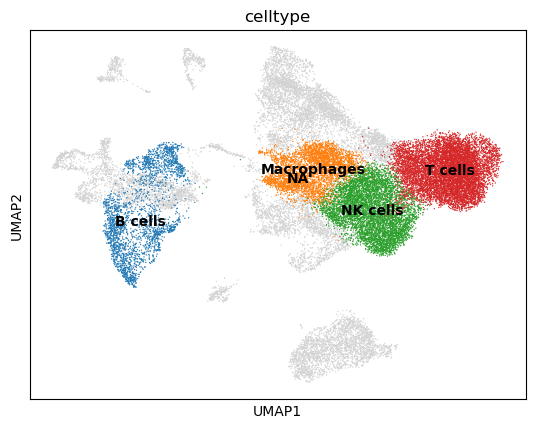

In [14]:
sc.pl.umap(
    adata1_full,
    color="celltype",
    legend_loc="on data"
)

In [26]:
cluster_map_adata2 = {
    "0": "T cells",
    "1": "T cells",
    "2": "Endothelial",
    "3": "Macrophages",
    "4": "T cells",
    "5": "Fibroblasts",
    "6": "Fibroblasts",
    "7": "T cells",
    "8": "T cells",
    "9": "NK cells",
    "10": "NK cells",
    "11": "Tumour epithelial",
    "12": "Macrophages",
    "13": "Tumour epithelial",
    "14": "Tumour epithelial",
    "15": "B cells",
    "16": "Tumour epithelial",
    "17": "Tumour epithelial",
    "18": "Tumour epithelial",
    "19": "Tumour epithelial",
    "20": "Tumour epithelial",
    "21": "Tumour epithelial",
    "22": "T cells",
    "23": "Tumour epithelial",
    "24": "Tumour epithelial",
    "25": "Mesenchymal-like",
    "26": "B cells",
    "27": "B cells",
    "28": "Tumour epithelial",
    "29": "Plasma cells",
    "30": "T cells",
    "31": "Dendritic cells"
}

In [27]:
adata2_full.obs["celltype_broad"] = (
    adata2_full.obs["leiden"]
    .map(cluster_map_adata2)
)

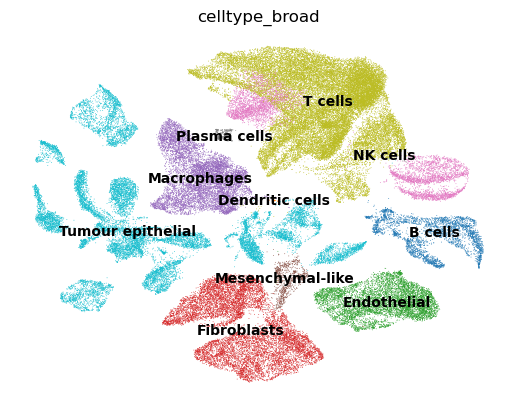

In [28]:
sc.pl.umap(
    adata2_full,
    color="celltype_broad",
    legend_loc="on data",
    frameon=False
)

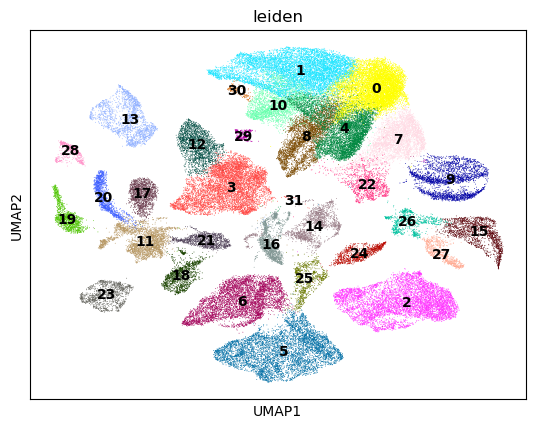

In [21]:
sc.pl.umap(
    adata2_full,
    color=["leiden"],
    legend_loc="on data"
)

In [23]:
sc.tl.rank_genes_groups(
    adata2_full,
    groupby="leiden",
    method="wilcoxon"
)

C:\Users\annam\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
C:\Users\annam\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
C:\Users\annam\anaconda3\Lib\site-packages\scanpy\tools\_rank_genes_groups.py:463: PerformanceWarning: DataFrame is highly fragmented.  This is usually t

In [24]:
sc.get.rank_genes_groups_df(
    adata2_full,
    group="25"
).head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,LGALS1,47.702171,4.480038,0.000000e+00,0.000000e+00
1,VIM,45.740078,3.591618,0.000000e+00,0.000000e+00
2,RPL22L1,45.476055,4.056298,0.000000e+00,0.000000e+00
3,GAPDH,44.618191,2.540222,0.000000e+00,0.000000e+00
4,PFN2,42.488617,4.922991,0.000000e+00,0.000000e+00
5,TPM4,42.097443,3.151298,0.000000e+00,0.000000e+00
6,S100A6,40.760483,2.878536,0.000000e+00,0.000000e+00
7,ANXA2,40.221012,3.139328,0.000000e+00,0.000000e+00
8,PGAM1,39.968269,3.082969,0.000000e+00,0.000000e+00
9,ASPH,39.913834,4.650178,0.000000e+00,0.000000e+00


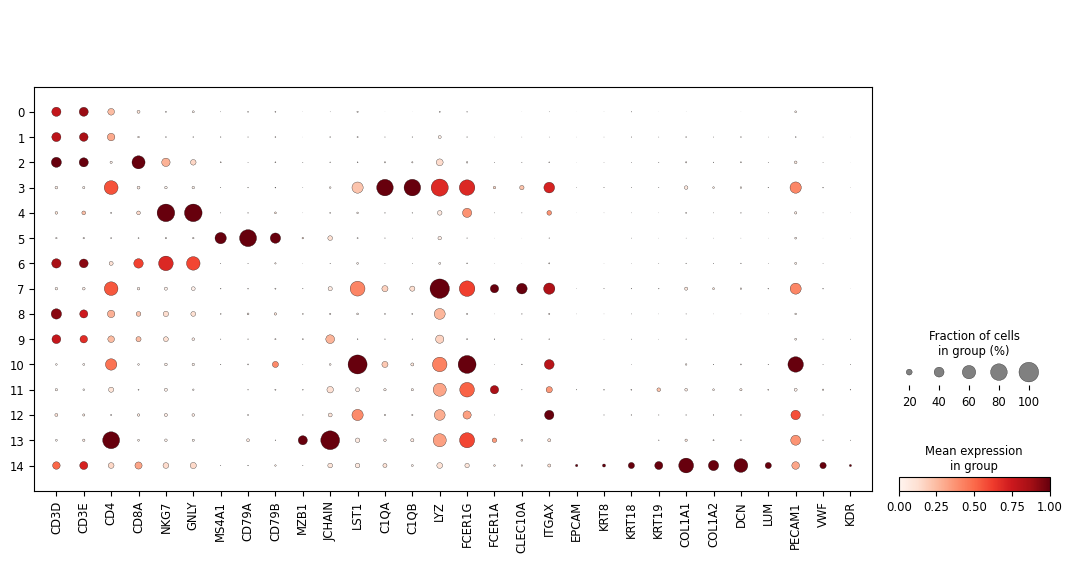

In [29]:
broad_markers = [
    "CD3D", "CD3E", "CD4", "CD8A", "NKG7", "GNLY",
    "MS4A1", "CD79A", "CD79B", "MZB1", "JCHAIN",
    "LST1", "C1QA", "C1QB", "LYZ", "FCER1G",
    "FCER1A", "CLEC10A", "ITGAX",
    "EPCAM", "KRT8", "KRT18", "KRT19",
    "COL1A1", "COL1A2", "DCN", "LUM",
    "PECAM1", "VWF", "KDR"
]

broad_markers_present = [
    g for g in broad_markers
    if g in adata1_full.var_names
]

sc.pl.dotplot(
    adata1_full,
    var_names=broad_markers_present,
    groupby="leiden",
    standard_scale="var"
)

In [30]:
cluster_map_adata1 = {
    "0": "T cells",
    "1": "T cells",
    "2": "T cells",
    "3": "Macrophages",
    "4": "NK cells",
    "5": "Cytotoxic lymphoid",
    "6": "T cells",
    "7": "Macrophages",
    "8": "T cells",
    "9": "T cells",
    "10": "Endothelial-like",
    "11": "Macrophages",
    "12": "Macrophages",
    "13": "Macrophages",
    "14": "Fibroblasts"
}

In [31]:
adata1_full.obs["celltype_broad"] = (
    adata1_full.obs["leiden"]
    .map(cluster_map_adata1)
)

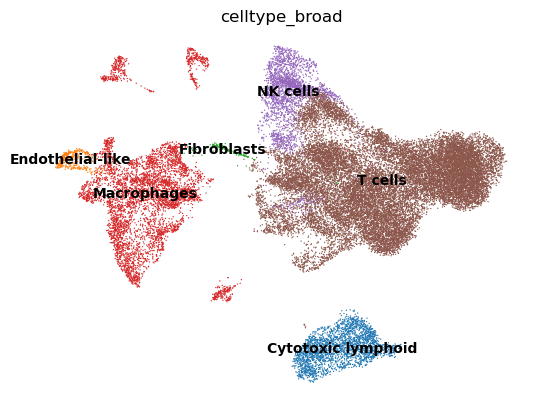

In [32]:
sc.pl.umap(
    adata1_full,
    color="celltype_broad",
    legend_loc="on data",
    frameon=False
)

In [33]:
adata1_full.write("GSE114725_annotated.h5ad")
adata2_full.write("GSE176078_annotated.h5ad")

In [34]:
adata1_full.obs["celltype_broad"].value_counts()
adata2_full.obs["celltype_broad"].value_counts()

celltype_broad
T cells              30586
Tumour epithelial    16987
Fibroblasts          10460
Macrophages           8471
Endothelial           6503
NK cells              5440
B cells               3295
Mesenchymal-like       886
Plasma cells           310
Dendritic cells         16
Name: count, dtype: int64

C:\Users\annam\AppData\Local\Temp\ipykernel_9332\2793072753.py:1: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata1_full, color="celltype_broad", legend_loc="on data", frameon=False, save="_GSE114725_celltype_broad.png")


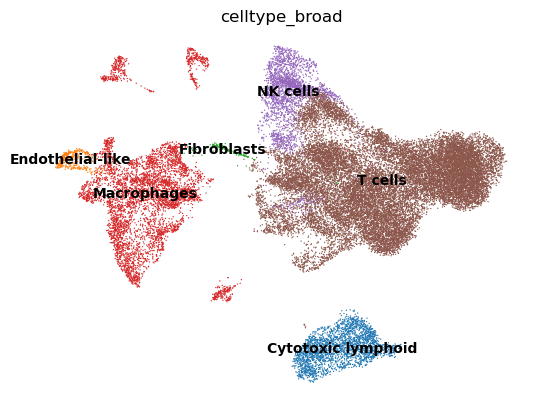

C:\Users\annam\AppData\Local\Temp\ipykernel_9332\2793072753.py:2: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata2_full, color="celltype_broad", legend_loc="on data", frameon=False, save="_GSE176078_celltype_broad.png")


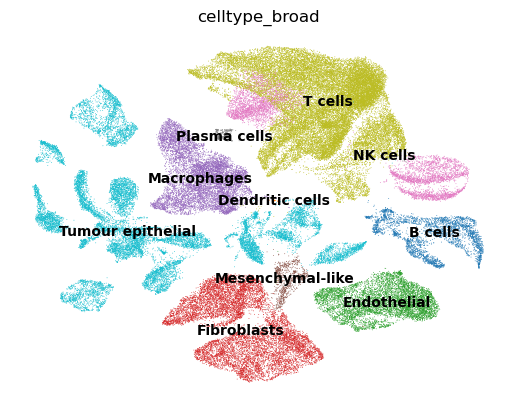

In [35]:
sc.pl.umap(adata1_full, color="celltype_broad", legend_loc="on data", frameon=False, save="_GSE114725_celltype_broad.png")
sc.pl.umap(adata2_full, color="celltype_broad", legend_loc="on data", frameon=False, save="_GSE176078_celltype_broad.png")